# MatchPotential: Predicting Mutual Match Count

**Project overview**

- **Project name:** MatchPotential
- **Assignment theme:** Tying the Data Knot: Love, Life & Likes
- **Course:** WIA1006/WID3006 Machine Learning
- **Group:** OCC 7 Group 7
- **Group members**

| Name | Matric No. |
|---|---:|
| LIM HONG ZHANG | 25006100 |
| TAN CHEE KEAT | 25006123 |
| KHOR KAI YEE | 25005596 |
| JOE VEI XIANG ZU | 25005541 |
| DERIC ING QUAN CHONG | 25005537 |
| TAN ZI XIANG | 24237108 |

- **Dataset source:** Kaggle Dating App Behavior Dataset  
  https://www.kaggle.com/datasets/keyushnisar/dating-app-behavior-dataset
- **Task type:** Supervised regression
- **Target variable:** `mutual_matches`

## 1. Environment and Imports

This section installs the AutoML package and imports the libraries used for data analysis, preprocessing, modelling, and evaluation.


In [ ]:
# Install FLAML for AutoML benchmark in Google Colab
!pip -q install "flaml[automl]"

# Standard libraries
from pathlib import Path
import numpy as np
import pandas as pd

# Google Drive
from google.colab import drive

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Lasso, LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, roc_auc_score
from sklearn.model_selection import ParameterGrid, RandomizedSearchCV, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor

# XGBoost
from xgboost import XGBRegressor

# FLAML AutoML
from flaml import AutoML

RANDOM_STATE = 42
TEST_SIZE = 0.20
TUNING_N_ITER = 10

sns.set_theme(style="whitegrid", palette="Set2")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.6/223.6 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.7/349.7 kB 17.2 MB/s eta 0:00:00


### Notebook Setup Helper Functions

We keep repeated preprocessing and evaluation code here so the modelling sections are easier to read.


In [ ]:
def split_comma_tags(text):
    if pd.isna(text):
        return []
    return [tag.strip().lower() for tag in str(text).split(",") if tag.strip()]


def flatten_text_column(values):
    return np.asarray(values).ravel()


def build_preprocessor(X_data):
    tag_column = "interest_tags"
    numeric_columns = X_data.select_dtypes(include=["number"]).columns.tolist()
    categorical_columns = [
        column
        for column in X_data.select_dtypes(exclude=["number"]).columns.tolist()
        if column != tag_column
    ]

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    tag_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="")),
            ("flatten", FunctionTransformer(flatten_text_column, validate=False)),
            ("vectorizer", CountVectorizer(tokenizer=split_comma_tags, token_pattern=None, lowercase=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_columns),
            ("cat", categorical_pipeline, categorical_columns),
            ("tags", tag_pipeline, [tag_column]),
        ],
        remainder="drop",
        sparse_threshold=0.0,
    )


def calculate_regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
    }


def evaluate_models(models_dict, X_train, y_train, X_test, y_test, baseline_rmse=None):
    rows = []
    fitted_models = {}

    for model_name, estimator in models_dict.items():
        print(f"Training {model_name}...")
        pipeline = Pipeline(
            steps=[
                ("preprocessor", build_preprocessor(X_train)),
                ("model", estimator),
            ]
        )
        pipeline.fit(X_train, y_train)
        predictions = np.clip(pipeline.predict(X_test), 0, 30)
        metrics = calculate_regression_metrics(y_test, predictions)
        metrics["Model"] = model_name
        rows.append(metrics)
        fitted_models[model_name] = pipeline

    results = pd.DataFrame(rows).set_index("Model").sort_values("R2", ascending=False)
    if baseline_rmse is not None:
        results["RMSE Improvement vs Dummy"] = baseline_rmse - results["RMSE"]
    return results, fitted_models


def add_engineered_features(data):
    engineered = data.copy()
    engineered["likes_per_minute"] = engineered["likes_received"] / (engineered["app_usage_time_min"] + 1)
    engineered["messages_per_minute"] = engineered["message_sent_count"] / (engineered["app_usage_time_min"] + 1)
    engineered["swipe_like_interaction"] = engineered["swipe_right_ratio"] * engineered["likes_received"]
    engineered["bio_length_bin"] = pd.cut(engineered["bio_length"], bins=4, labels=False, include_lowest=True)
    engineered["age_group"] = pd.cut(engineered["age"], bins=[18, 25, 35, 45, 60, 100], labels=False, include_lowest=True)
    engineered["bmi"] = engineered["weight_kg"] / ((engineered["height_cm"] / 100) ** 2)
    return engineered


def get_feature_names(fitted_preprocessor):
    feature_names = []
    for transformer_name, transformer, columns in fitted_preprocessor.transformers_:
        if transformer_name == "num":
            feature_names.extend(list(columns))
        elif transformer_name == "cat":
            onehot = transformer.named_steps["onehot"]
            feature_names.extend(onehot.get_feature_names_out(columns))
        elif transformer_name == "tags":
            vectorizer = transformer.named_steps["vectorizer"]
            feature_names.extend([f"interest_tags__{tag}" for tag in vectorizer.get_feature_names_out()])
    return np.array(feature_names)


## 2. Problem Statement and Objectives

Dating app interactions can be represented using profile information, demographic attributes, user interests, app-usage behaviour, swipe patterns, likes, messages, and match outcomes. In this project, we investigate how these behavioural signals can be used in a machine learning workflow.

Before final modelling, we compare several possible target formulations from the dataset. The aim is to choose a task that is both relevant to the dating-app context and learnable from the available features.

The project objectives are:

1. Explore the provided dating app behaviour dataset.
2. Compare possible machine learning target formulations.
3. Select a final supervised learning task based on baseline improvement and dataset relevance.
4. Preprocess numerical, categorical, and interest-tag features.
5. Train, tune, and compare multiple machine learning models.
6. Interpret model performance, feature importance, limitations, and ethical concerns.


## 3. Data Acquisition

We load the provided CSV from Google Drive. Edit `data_path` if the file is stored in a different Drive location.


In [ ]:
drive.mount('/content/drive')
data_path = '/content/drive/My Drive/dating_app_behavior_dataset_extended1.csv'
df = pd.read_csv(data_path)

print(f"Dataset loaded from: {data_path}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")
display(df.head())


Mounted at /content/drive
Dataset loaded from: /content/drive/My Drive/dating_app_behavior_dataset_extended1.csv
Rows: 50,000
Columns: 25


,gender,sexual_orientation,location_type,income_bracket,education_level,interest_tags,app_usage_time_min,app_usage_time_label,swipe_right_ratio,swipe_right_label,...,emoji_usage_rate,last_active_hour,swipe_time_of_day,match_outcome,age,height_cm,weight_kg,zodiac_sign,body_type,relationship_intent
0,Prefer Not to Say,Gay,Urban,High,Bachelor’s,"Fitness, Politics, Traveling",52,Moderate,0.60,Optimistic,...,0.36,13,Early Morning,Mutual Match,56,149,40.6,Taurus,Curvy,Friends Only
1,Male,Bisexual,Suburban,Upper-Middle,No Formal Education,"Languages, Fashion, Parenting",279,Extreme User,0.56,Optimistic,...,0.42,0,Morning,Chat Ignored,40,155,69.7,Leo,Plus Size,Hookups
2,Non-binary,Pansexual,Suburban,Low,Master’s,"Movies, Reading, DIY",49,Moderate,0.41,Optimistic,...,0.41,1,After Midnight,Date Happened,30,185,96.9,Sagittarius,Curvy,Serious Relationship
3,Genderfluid,Gay,Metro,Very Low,Postdoc,"Coding, Podcasts, History",185,Extreme User,0.32,Balanced,...,0.07,21,Morning,No Action,57,154,49.3,Taurus,Slim,Exploring
4,Male,Bisexual,Urban,Middle,Bachelor’s,"Clubbing, Podcasts, Cars",83,High,0.32,Balanced,...,0.11,22,After Midnight,One-sided Like,24,149,40.0,Libra,Slim,Casual Dating


## 4. Data Quality Check

We check the dataset structure, data types, missing values, duplicate rows, and basic target statistics before modelling.


In [ ]:
print("Column names:")
print(df.columns.tolist())

print("\nDataFrame info:")
df.info()

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

missing_summary = df.isna().sum().to_frame("missing_count")
missing_summary["missing_percent"] = 100 * missing_summary["missing_count"] / len(df)
display(missing_summary.sort_values("missing_count", ascending=False))

quality_summary = pd.DataFrame({
    "metric": ["rows", "columns", "missing_values", "duplicate_rows", "target_min", "target_max", "target_mean", "target_median", "target_std", "target_unique_values"],
    "value": [
        df.shape[0],
        df.shape[1],
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["mutual_matches"].min(),
        df["mutual_matches"].max(),
        df["mutual_matches"].mean(),
        df["mutual_matches"].median(),
        df["mutual_matches"].std(),
        df["mutual_matches"].nunique(),
    ],
})
display(quality_summary)

display(df.describe(include="all").T)


Column names:
['gender', 'sexual_orientation', 'location_type', 'income_bracket', 'education_level', 'interest_tags', 'app_usage_time_min', 'app_usage_time_label', 'swipe_right_ratio', 'swipe_right_label', 'likes_received', 'mutual_matches', 'profile_pics_count', 'bio_length', 'message_sent_count', 'emoji_usage_rate', 'last_active_hour', 'swipe_time_of_day', 'match_outcome', 'age', 'height_cm', 'weight_kg', 'zodiac_sign', 'body_type', 'relationship_intent']

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                50000 non-null  object 
 1   sexual_orientation    50000 non-null  object 
 2   location_type         50000 non-null  object 
 3   income_bracket        50000 non-null  object 
 4   education_level       50000 non-null  object 
 5   interest_tags         50000 non-null  object 
 6  

,dtype
gender,object
sexual_orientation,object
location_type,object
income_bracket,object
education_level,object
interest_tags,object
app_usage_time_min,int64
app_usage_time_label,object
swipe_right_ratio,float64
swipe_right_label,object


,missing_count,missing_percent
gender,0,0.0
sexual_orientation,0,0.0
location_type,0,0.0
income_bracket,0,0.0
education_level,0,0.0
interest_tags,0,0.0
app_usage_time_min,0,0.0
app_usage_time_label,0,0.0
swipe_right_ratio,0,0.0
swipe_right_label,0,0.0


,metric,value
0,rows,50000.000000
1,columns,25.000000
2,missing_values,0.000000
3,duplicate_rows,0.000000
4,target_min,0.000000
5,target_max,30.000000
6,target_mean,13.870280
7,target_median,13.000000
8,target_std,9.105615
9,target_unique_values,31.000000


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,50000,6,Female,8384,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sexual_orientation,50000,8,Straight,6326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location_type,50000,6,Remote Area,8519,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income_bracket,50000,7,High,7309,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,50000,9,Bachelor’s,5646,NaN,NaN,NaN,NaN,NaN,NaN,NaN
interest_tags,50000,40206,"Fitness, Anime, Yoga",6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
app_usage_time_min,50000.0,NaN,NaN,NaN,149.9124,86.990521,0.0,74.0,150.0,225.0,300.0
app_usage_time_label,50000,7,Extreme User,20140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
swipe_right_ratio,50000.0,NaN,NaN,NaN,0.500655,0.197468,0.0,0.37,0.5,0.64,1.0
swipe_right_label,50000,4,Optimistic,26873,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Target Discovery and Final Task Definition

Before final modelling, we run a small target-discovery experiment inside this notebook. The goal is only to compare possible target choices quickly, not to tune final models.

We compare the original `match_outcome` classification task, a binary match-success classification task, and `mutual_matches` regression using fast linear benchmarks against dummy baselines.


,Candidate Problem,Task Type,Baseline Metric,Model Metric,Improvement over Baseline,Relative Improvement (%),Supporting Metric,Decision
0,Original match_outcome classification,classification,0.102200,0.102700,0.000500,0.489237,macro F1: 0.102,Not selected: lower relative improvement
1,Match Success vs Match Failure classification,classification,0.603000,0.603000,0.000000,0.000000,ROC-AUC: 0.493,Not selected: lower relative improvement
2,mutual_matches regression,regression,9.084348,8.941935,0.142413,1.567671,R²: 0.031,Selected: highest relative improvement


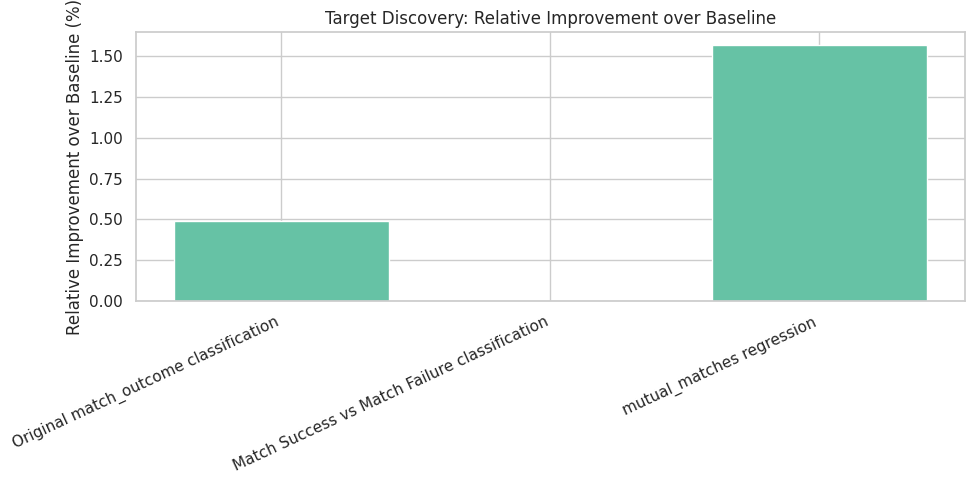

In [ ]:
target_discovery_df = df.copy()
success_outcomes = ["Mutual Match", "Instant Match", "Date Happened", "Relationship Formed"]
target_discovery_df["match_success"] = target_discovery_df["match_outcome"].isin(success_outcomes).astype(int)

discovery_drop_columns = [
    "match_outcome",
    "mutual_matches",
    "app_usage_time_label",
    "swipe_right_label",
    "match_success",
]
X_discovery = target_discovery_df.drop(columns=discovery_drop_columns)

classification_benchmark = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
regression_benchmark = Ridge(alpha=1.0)


def evaluate_classification_target(candidate_name, y, supporting_metric_name):
    X_train_disc, X_test_disc, y_train_disc, y_test_disc = train_test_split(
        X_discovery,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=y,
    )

    dummy_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train_disc)),
        ("model", DummyClassifier(strategy="most_frequent")),
    ])
    model_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train_disc)),
        ("model", clone(classification_benchmark)),
    ])

    dummy_pipeline.fit(X_train_disc, y_train_disc)
    model_pipeline.fit(X_train_disc, y_train_disc)

    dummy_pred = dummy_pipeline.predict(X_test_disc)
    model_pred = model_pipeline.predict(X_test_disc)

    baseline_accuracy = accuracy_score(y_test_disc, dummy_pred)
    model_accuracy = accuracy_score(y_test_disc, model_pred)
    improvement = model_accuracy - baseline_accuracy
    relative_improvement = (improvement / baseline_accuracy) * 100 if baseline_accuracy != 0 else np.nan

    if supporting_metric_name == "macro F1":
        supporting_metric = f1_score(y_test_disc, model_pred, average="macro", zero_division=0)
    else:
        try:
            model_score = model_pipeline.predict_proba(X_test_disc)[:, 1]
            supporting_metric = roc_auc_score(y_test_disc, model_score)
        except Exception:
            supporting_metric = np.nan

    return {
        "Candidate Problem": candidate_name,
        "Task Type": "classification",
        "Baseline Metric": baseline_accuracy,
        "Model Metric": model_accuracy,
        "Improvement over Baseline": improvement,
        "Relative Improvement (%)": relative_improvement,
        "Supporting Metric": (
            f"{supporting_metric_name}: {supporting_metric:.3f}"
            if pd.notna(supporting_metric)
            else f"{supporting_metric_name}: not available"
        ),
    }


def evaluate_regression_target(candidate_name, y):
    X_train_disc, X_test_disc, y_train_disc, y_test_disc = train_test_split(
        X_discovery,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    dummy_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train_disc)),
        ("model", DummyRegressor(strategy="mean")),
    ])
    model_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train_disc)),
        ("model", clone(regression_benchmark)),
    ])

    dummy_pipeline.fit(X_train_disc, y_train_disc)
    model_pipeline.fit(X_train_disc, y_train_disc)

    dummy_pred = np.clip(dummy_pipeline.predict(X_test_disc), 0, 30)
    model_pred = np.clip(model_pipeline.predict(X_test_disc), 0, 30)

    dummy_rmse = np.sqrt(mean_squared_error(y_test_disc, dummy_pred))
    model_rmse = np.sqrt(mean_squared_error(y_test_disc, model_pred))
    improvement = dummy_rmse - model_rmse
    relative_improvement = (improvement / dummy_rmse) * 100 if dummy_rmse != 0 else np.nan
    model_r2 = r2_score(y_test_disc, model_pred)

    return {
        "Candidate Problem": candidate_name,
        "Task Type": "regression",
        "Baseline Metric": dummy_rmse,
        "Model Metric": model_rmse,
        "Improvement over Baseline": improvement,
        "Relative Improvement (%)": relative_improvement,
        "Supporting Metric": f"R²: {model_r2:.3f}",
    }


target_discovery_rows = [
    evaluate_classification_target(
        "Original match_outcome classification",
        target_discovery_df["match_outcome"],
        "macro F1",
    ),
    evaluate_classification_target(
        "Match Success vs Match Failure classification",
        target_discovery_df["match_success"],
        "ROC-AUC",
    ),
    evaluate_regression_target(
        "mutual_matches regression",
        target_discovery_df["mutual_matches"],
    ),
]

target_discovery_results = pd.DataFrame(target_discovery_rows)

best_target_index = target_discovery_results["Relative Improvement (%)"].idxmax()
best_target_name = target_discovery_results.loc[best_target_index, "Candidate Problem"]

target_discovery_results["Decision"] = np.where(
    target_discovery_results.index == best_target_index,
    "Selected: highest relative improvement",
    "Not selected: lower relative improvement",
)

styled_target_discovery = (
    target_discovery_results.style
    .format({
        "Baseline Metric": "{:.6f}",
        "Model Metric": "{:.6f}",
        "Improvement over Baseline": "{:.6f}",
        "Relative Improvement (%)": "{:.6f}",
    })
    .set_properties(
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Candidate Problem"],
        **{
            "min-width": "240px",
            "max-width": "280px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Decision"],
        **{
            "min-width": "280px",
            "max-width": "340px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Supporting Metric"],
        **{
            "min-width": "170px",
            "max-width": "220px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("vertical-align", "middle"),
                ("white-space", "normal"),
                ("font-weight", "bold"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "left"),
                ("vertical-align", "middle"),
                ("white-space", "normal"),
            ],
        },
    ])
)

display(styled_target_discovery)

plt.figure(figsize=(10, 5))
plt.bar(target_discovery_results["Candidate Problem"], target_discovery_results["Relative Improvement (%)"])
plt.title("Target Discovery: Relative Improvement over Baseline")
plt.ylabel("Relative Improvement over Baseline (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

Based on the target-discovery table and relative-improvement chart, `mutual_matches` regression is selected because it achieved the highest relative improvement over its dummy baseline among the tested candidate tasks. Although the improvement is still modest, it provides a clearer modelling signal than the classification targets.

Since `mutual_matches` is a numeric count variable ranging from 0 to 30, the final task is treated as supervised regression. More complex regression models are evaluated in the later model comparison and tuning sections.


## 6. Exploratory Data Analysis

We explore the target distribution and relationships between mutual matches and behavioural, demographic, and interest features before preprocessing.


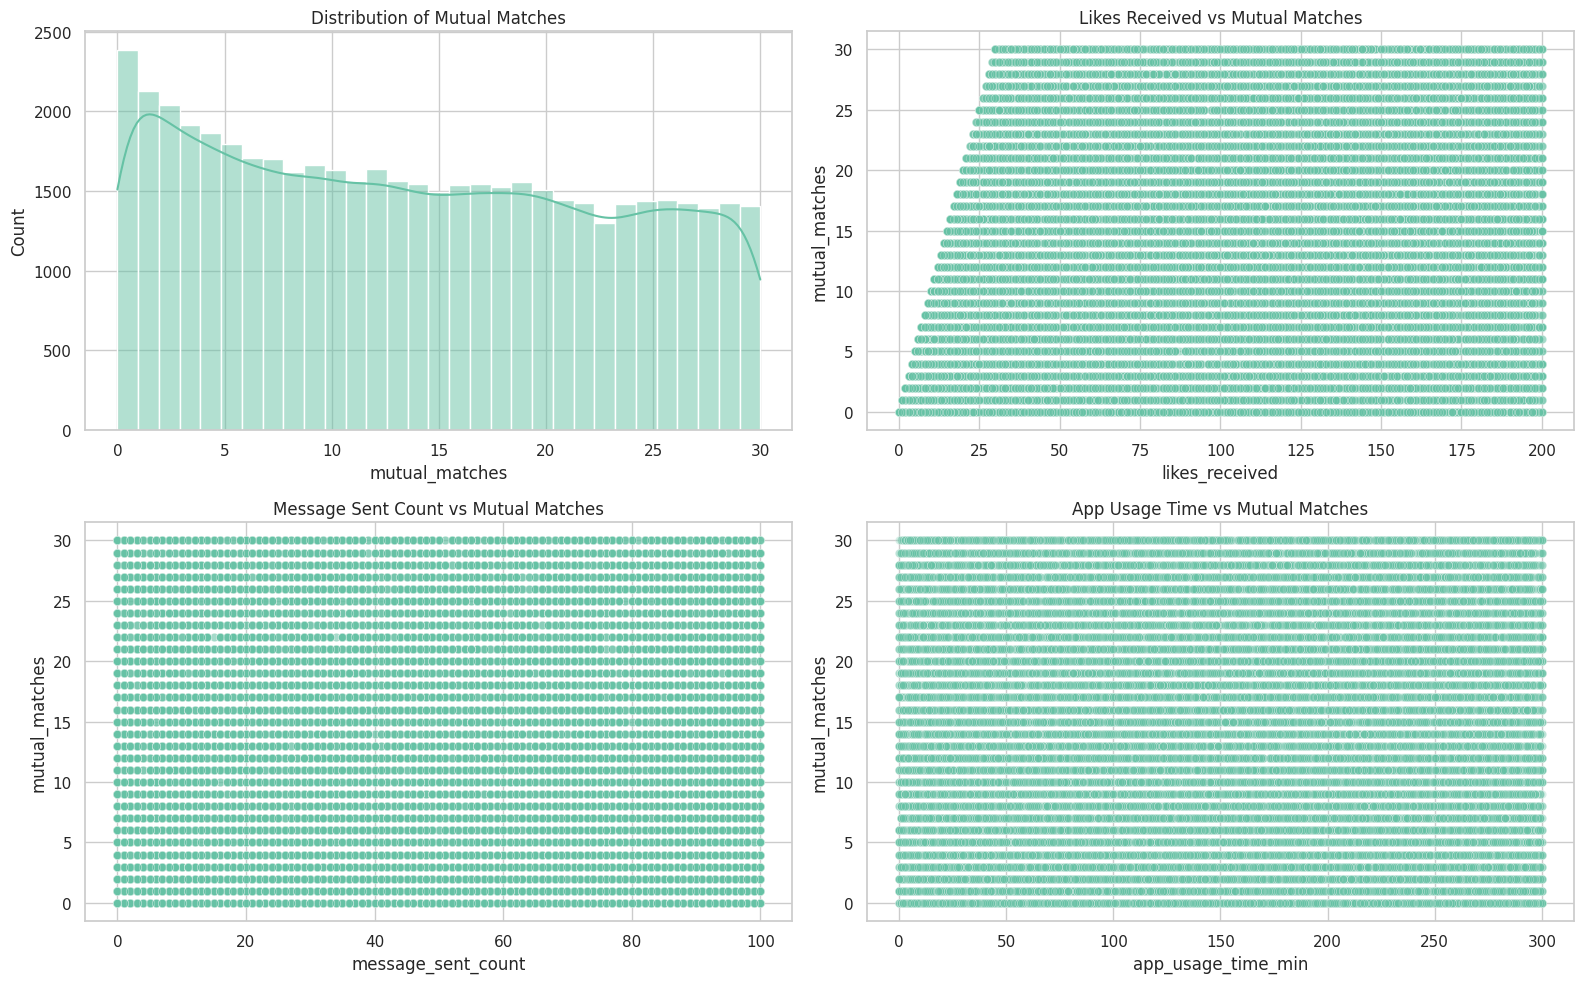

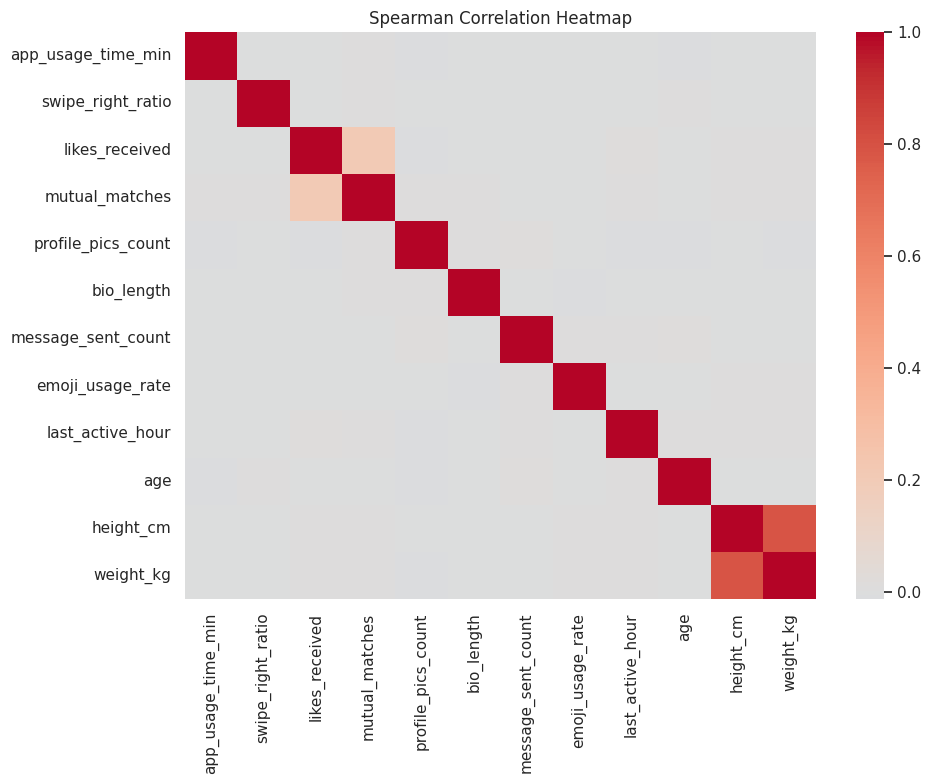

Numerical correlations with mutual_matches:


,pearson,spearman,abs_spearman
likes_received,0.205968,0.210137,0.210137
height_cm,0.010265,0.010027,0.010027
weight_kg,0.008814,0.008578,0.008578
app_usage_time_min,0.008318,0.008200,0.008200
bio_length,0.005855,0.005708,0.005708
profile_pics_count,0.005483,0.005688,0.005688
message_sent_count,-0.004002,-0.003802,0.003802
swipe_right_ratio,0.004139,0.003384,0.003384
last_active_hour,0.003438,0.003338,0.003338
age,0.000990,0.001133,0.001133


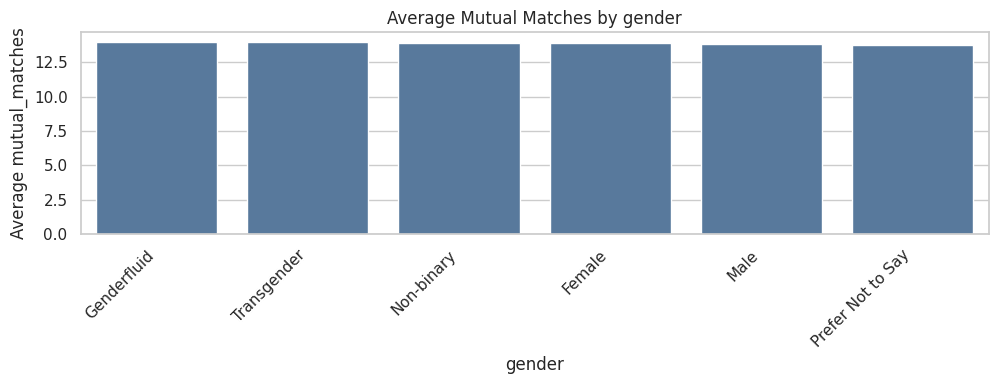

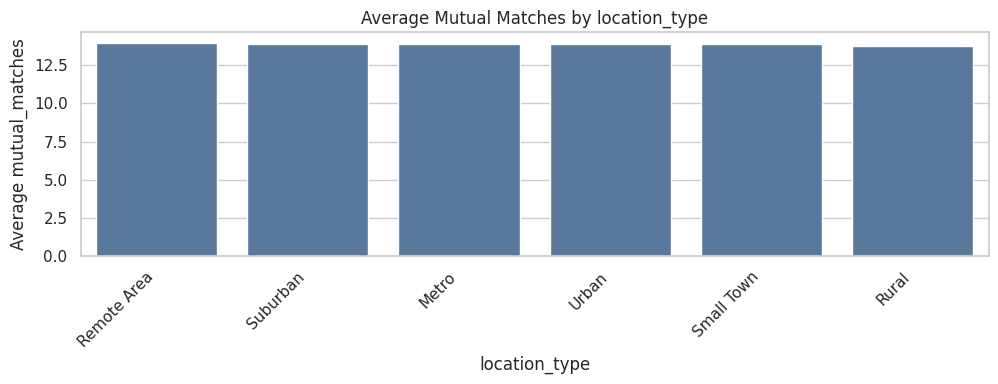

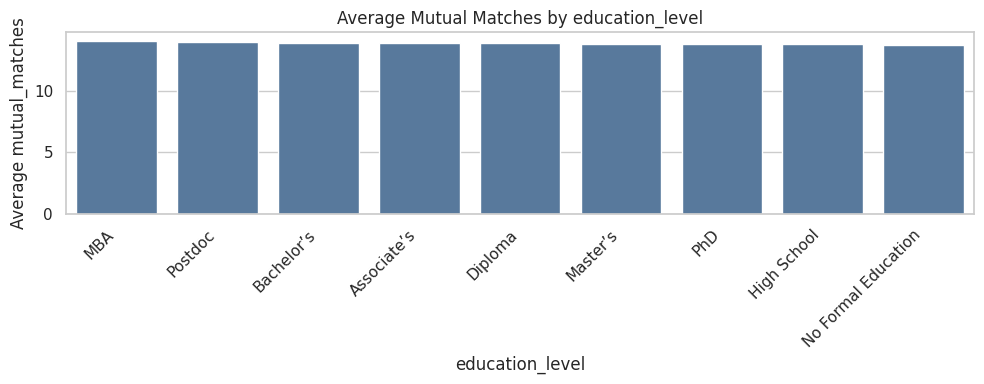

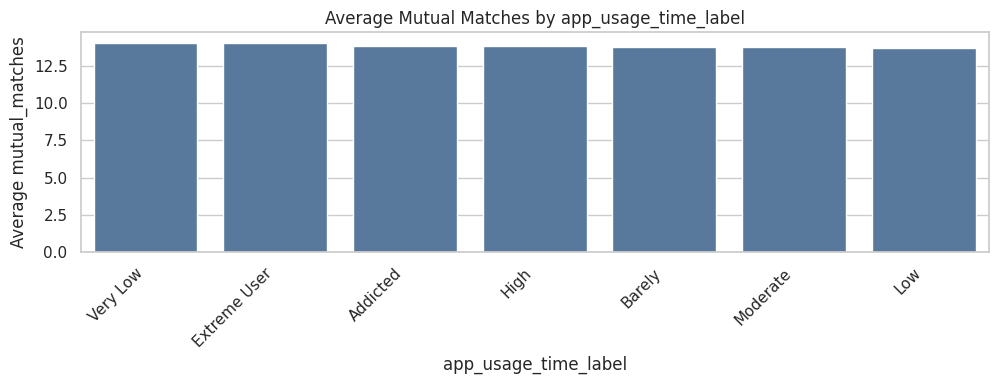

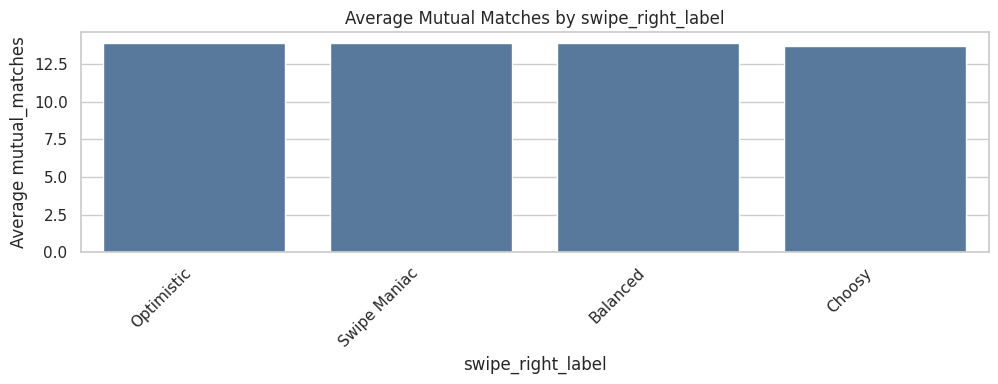

,count,mean
tag,,
poetry,2990,14.229097
writing,3050,14.158361
meditation,2985,14.136683
k-pop,3022,14.131039
podcasts,3069,14.109808
yoga,3108,14.091699
motorcycling,3140,14.070382
astrology,3001,14.052649
spirituality,3085,14.022042


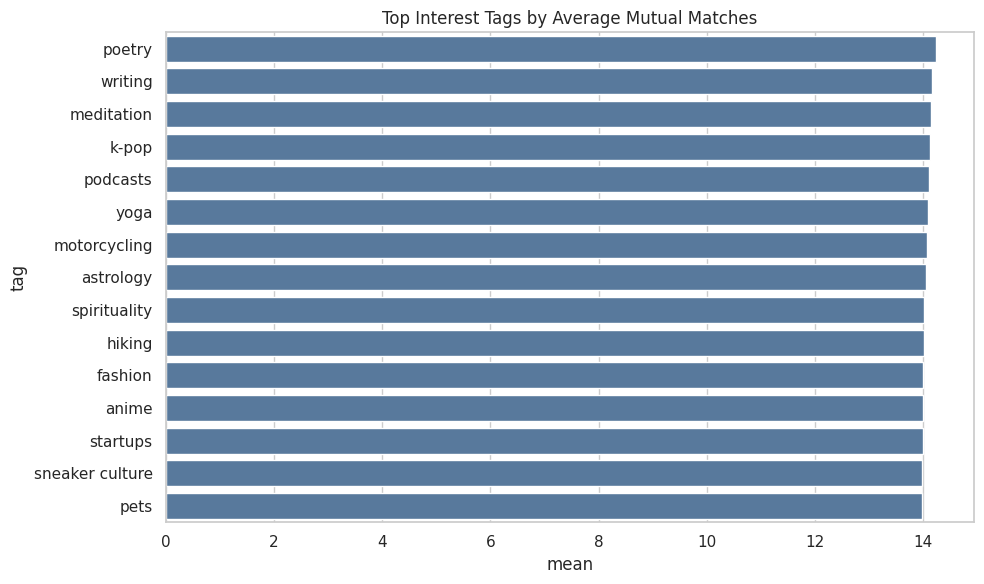

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.histplot(df["mutual_matches"], bins=31, kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Mutual Matches")

sns.scatterplot(data=df, x="likes_received", y="mutual_matches", alpha=0.25, ax=axes[0, 1])
axes[0, 1].set_title("Likes Received vs Mutual Matches")

sns.scatterplot(data=df, x="message_sent_count", y="mutual_matches", alpha=0.25, ax=axes[1, 0])
axes[1, 0].set_title("Message Sent Count vs Mutual Matches")

sns.scatterplot(data=df, x="app_usage_time_min", y="mutual_matches", alpha=0.25, ax=axes[1, 1])
axes[1, 1].set_title("App Usage Time vs Mutual Matches")
plt.tight_layout()
plt.show()

numeric_corr = df.select_dtypes(include=["number"]).corr(method="spearman")
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_corr, cmap="coolwarm", center=0)
plt.title("Spearman Correlation Heatmap")
plt.tight_layout()
plt.show()
pearson_target_table = df.select_dtypes(include=["number"]).corr(method="pearson")[["mutual_matches"]].rename(columns={"mutual_matches": "pearson"})
spearman_target_table = df.select_dtypes(include=["number"]).corr(method="spearman")[["mutual_matches"]].rename(columns={"mutual_matches": "spearman"})
target_correlation_table = pearson_target_table.join(spearman_target_table)
target_correlation_table = target_correlation_table.drop(index="mutual_matches").assign(
    abs_spearman=lambda data: data["spearman"].abs()
).sort_values("abs_spearman", ascending=False)
print("Numerical correlations with mutual_matches:")
display(target_correlation_table)

for column in ["gender", "location_type", "education_level", "app_usage_time_label", "swipe_right_label"]:
    means = df.groupby(column)["mutual_matches"].mean().sort_values(ascending=False)
    plt.figure(figsize=(10, 4))
    sns.barplot(x=means.index, y=means.values, color="#4C78A8")
    plt.title(f"Average Mutual Matches by {column}")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Average mutual_matches")
    plt.tight_layout()
    plt.show()

tag_df = df[["interest_tags", "mutual_matches"]].copy()
tag_df["tag"] = tag_df["interest_tags"].fillna("").str.split(",")
tag_df = tag_df.explode("tag")
tag_df["tag"] = tag_df["tag"].str.strip().str.lower()
tag_summary = tag_df[tag_df["tag"] != ""].groupby("tag")["mutual_matches"].agg(count="count", mean="mean").sort_values("mean", ascending=False)
display(tag_summary.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=tag_summary.head(15).reset_index(), x="mean", y="tag", color="#4C78A8")
plt.title("Top Interest Tags by Average Mutual Matches")
plt.tight_layout()
plt.show()


## 7. Train-Test Split

We split the raw dataframe before feature engineering. This keeps the final modelling flow clear and avoids creating model-ready features on the full dataset before the split.


In [ ]:
train_df_raw, test_df_raw = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df = train_df_raw.copy()
test_df = test_df_raw.copy()

print(f"Raw training rows: {train_df.shape[0]:,}")
print(f"Raw test rows: {test_df.shape[0]:,}")


Raw training rows: 40,000
Raw test rows: 10,000


## 8. Feature Engineering

We create extra features after the raw train-test split. None of these features uses `mutual_matches`, because that would leak the answer into the input data.


In [ ]:
feature_engineering_plan = pd.DataFrame([
    {"new_feature": "likes_per_minute", "reason": "Measures likes received relative to app usage time"},
    {"new_feature": "messages_per_minute", "reason": "Measures messaging activity relative to app usage time"},
    {"new_feature": "swipe_like_interaction", "reason": "Combines swipe tendency with likes received"},
    {"new_feature": "bio_length_bin", "reason": "Groups profile bio length into broad categories"},
    {"new_feature": "age_group", "reason": "Captures non-linear age patterns"},
    {"new_feature": "bmi", "reason": "Combines height and weight into one body-size indicator"},
])
display(feature_engineering_plan)

train_df_model = add_engineered_features(train_df)
test_df_model = add_engineered_features(test_df)

engineered_features = [
    "likes_per_minute",
    "messages_per_minute",
    "swipe_like_interaction",
    "bio_length_bin",
    "age_group",
    "bmi",
]

display(train_df_model[engineered_features].describe().T)

engineered_corr = train_df_model[engineered_features + ["mutual_matches"]].corr(method="spearman")[["mutual_matches"]]
engineered_corr = engineered_corr.drop(index="mutual_matches").rename(columns={"mutual_matches": "spearman_with_target"})
engineered_corr["abs_spearman"] = engineered_corr["spearman_with_target"].abs()
display(engineered_corr.sort_values("abs_spearman", ascending=False))


,new_feature,reason
0,likes_per_minute,Measures likes received relative to app usage ...
1,messages_per_minute,Measures messaging activity relative to app us...
2,swipe_like_interaction,Combines swipe tendency with likes received
3,bio_length_bin,Groups profile bio length into broad categories
4,age_group,Captures non-linear age patterns
5,bmi,Combines height and weight into one body-size ...


,count,mean,std,min,25%,50%,75%,max
likes_per_minute,40000.0,2.084312,8.044419,0.000000,0.325417,0.662237,1.325758,198.000000
messages_per_minute,40000.0,1.059542,4.201452,0.000000,0.163424,0.329941,0.661791,100.000000
swipe_like_interaction,40000.0,49.732057,36.713532,0.000000,19.595000,43.090000,73.500000,198.000000
bio_length_bin,40000.0,1.497200,1.119162,0.000000,0.000000,1.000000,3.000000,3.000000
age_group,40000.0,1.707950,1.118297,0.000000,1.000000,2.000000,3.000000,3.000000
bmi,40000.0,23.993233,3.464883,17.978597,20.996053,24.000000,26.998444,30.016225


,spearman_with_target,abs_spearman
swipe_like_interaction,0.205034,0.205034
likes_per_minute,0.179620,0.179620
messages_per_minute,-0.006834,0.006834
bio_length_bin,0.004453,0.004453
bmi,0.004228,0.004228
age_group,0.001999,0.001999


## 9. Feature Set Definition and Leakage-Risk Check

After feature engineering, we define the final feature sets. The main model keeps engagement features, while the sensitivity feature set removes like-related and message-related variables to test how dependent the model is on those engagement signals.


In [ ]:
target = "mutual_matches"

main_drop_columns = [
    "mutual_matches",
    "match_outcome",
    "app_usage_time_label",
    "swipe_right_label",
]

safe_extra_drop_columns = [
    "likes_received",
    "message_sent_count",
    "likes_per_minute",
    "messages_per_minute",
    "swipe_like_interaction",
]

X_train = train_df_model.drop(columns=main_drop_columns)
y_train = train_df_model[target]

X_test = test_df_model.drop(columns=main_drop_columns)
y_test = test_df_model[target]

X_train_safe = train_df_model.drop(columns=main_drop_columns + safe_extra_drop_columns)
X_test_safe = test_df_model.drop(columns=main_drop_columns + safe_extra_drop_columns)

y_train_safe = y_train
y_test_safe = y_test

assert target not in X_train.columns
assert "match_outcome" not in X_train.columns
assert "likes_received" not in X_train_safe.columns
assert "message_sent_count" not in X_train_safe.columns

leakage_plan = pd.DataFrame([
    {"column": "mutual_matches", "decision": "drop", "reason": "target variable"},
    {"column": "match_outcome", "decision": "drop", "reason": "outcome label can leak match information"},
    {"column": "app_usage_time_label", "decision": "drop", "reason": "redundant label version of app_usage_time_min"},
    {"column": "swipe_right_label", "decision": "drop", "reason": "redundant label version of swipe_right_ratio"},
    {"column": "likes_received", "decision": "main model keeps; sensitivity model drops", "reason": "strong engagement signal but timing-dependent"},
    {"column": "message_sent_count", "decision": "main model keeps; sensitivity model drops", "reason": "may happen after match interaction"},
    {"column": "likes_per_minute / messages_per_minute / swipe_like_interaction", "decision": "sensitivity model drops", "reason": "derived from timing-dependent features"},
])
display(leakage_plan)

feature_group_table = pd.DataFrame([
    {"feature_group": "Profile and demographic", "examples": "age, gender, height_cm, weight_kg, body_type, education_level, income_bracket", "expected_signal": "Useful for interpretation, but may be weak alone"},
    {"feature_group": "Behaviour", "examples": "app_usage_time_min, swipe_right_ratio, swipe_time_of_day", "expected_signal": "Captures app activity and swipe tendency"},
    {"feature_group": "Engagement", "examples": "likes_received, message_sent_count, likes_per_minute, messages_per_minute, swipe_like_interaction", "expected_signal": "Strongest expected signal, but timing/leakage risk must be discussed"},
    {"feature_group": "Interest text", "examples": "interest_tags parsed using CountVectorizer", "expected_signal": "May capture preference patterns from user interests"},
])
display(feature_group_table)


,column,decision,reason
0,mutual_matches,drop,target variable
1,match_outcome,drop,outcome label can leak match information
2,app_usage_time_label,drop,redundant label version of app_usage_time_min
3,swipe_right_label,drop,redundant label version of swipe_right_ratio
4,likes_received,main model keeps; sensitivity model drops,strong engagement signal but timing-dependent
5,message_sent_count,main model keeps; sensitivity model drops,may happen after match interaction
6,likes_per_minute / messages_per_minute / swipe...,sensitivity model drops,derived from timing-dependent features


,feature_group,examples,expected_signal
0,Profile and demographic,"age, gender, height_cm, weight_kg, body_type, ...","Useful for interpretation, but may be weak alone"
1,Behaviour,"app_usage_time_min, swipe_right_ratio, swipe_t...",Captures app activity and swipe tendency
2,Engagement,"likes_received, message_sent_count, likes_per_...","Strongest expected signal, but timing/leakage ..."
3,Interest text,interest_tags parsed using CountVectorizer,May capture preference patterns from user inte...


## 10. Preprocessing Pipeline

We build the preprocessing summary using the training features. Numeric columns are imputed and scaled, normal categorical columns are one-hot encoded, and `interest_tags` is processed with `CountVectorizer` using comma-separated tags.


In [ ]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [
    column for column in X_train.select_dtypes(exclude=["number"]).columns.tolist()
    if column != "interest_tags"
]

preprocessing_summary = pd.DataFrame([
    {"feature_type": "numeric", "count": len(numeric_features), "method": "SimpleImputer(median) + StandardScaler"},
    {"feature_type": "categorical", "count": len(categorical_features), "method": "SimpleImputer(most_frequent) + OneHotEncoder"},
    {"feature_type": "interest_tags", "count": 1, "method": "CountVectorizer with comma-separated tokenizer"},
])
display(preprocessing_summary)

print(f"Main train shape: {X_train.shape}")
print(f"Main test shape: {X_test.shape}")
print(f"Sensitivity train shape: {X_train_safe.shape}")
print(f"Sensitivity test shape: {X_test_safe.shape}")


,feature_type,count,method
0,numeric,17,SimpleImputer(median) + StandardScaler
1,categorical,9,SimpleImputer(most_frequent) + OneHotEncoder
2,interest_tags,1,CountVectorizer with comma-separated tokenizer


Main train shape: (40000, 27)
Main test shape: (10000, 27)
Sensitivity train shape: (40000, 22)
Sensitivity test shape: (10000, 22)


## 11. Dummy Baseline

We train a `DummyRegressor` first. This is the baseline that our models need to beat.


In [ ]:
dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(X_train)),
        ("model", DummyRegressor(strategy="mean")),
    ]
)
dummy_pipeline.fit(X_train, y_train)
dummy_predictions = np.clip(dummy_pipeline.predict(X_test), 0, 30)
dummy_metrics = calculate_regression_metrics(y_test, dummy_predictions)

baseline_results = pd.DataFrame([{ "Model": "Dummy Mean", **dummy_metrics }]).set_index("Model")
display(baseline_results)

print("DummyRegressor is our baseline. A useful model should reduce RMSE and achieve higher R2 than this baseline.")


,MAE,RMSE,R2
Model,,,
Dummy Mean,7.889888,9.084348,-0.000067


DummyRegressor is our baseline. A useful model should reduce RMSE and achieve higher R2 than this baseline.


## 12. Model Selection: Compare 9 Regression Models

We compare 9 regression models for predicting `mutual_matches`. The models include linear, regularised linear, distance-based, tree-based, bagging, boosting, and XGBoost approaches.

`DummyRegressor` is evaluated separately as a baseline. It is used only to measure whether the trained models improve over a simple mean prediction.


In [ ]:
initial_models = {
    "Linear Regression": LinearRegression(n_jobs=-1),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.01, max_iter=10000, random_state=RANDOM_STATE),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=35, weights="distance", n_jobs=-1),
    "Decision Tree": DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=120, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(max_iter=150, random_state=RANDOM_STATE),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

model_results, fitted_models = evaluate_models(
    initial_models,
    X_train,
    y_train,
    X_test,
    y_test,
    baseline_rmse=dummy_metrics["RMSE"],
)
display(model_results)

model_count = len(initial_models)
print(f"Regression models compared: {model_count}")
print("DummyRegressor is used separately as the baseline.")

best_initial_model_name = model_results.sort_values("RMSE").index[0]
print(f"Best initial model by RMSE: {best_initial_model_name}")


Training Linear Regression...
Training Ridge Regression...
Training Lasso Regression...
Training KNN Regressor...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...
Training Hist Gradient Boosting...
Training XGBoost...


,MAE,RMSE,R2,RMSE Improvement vs Dummy
Model,,,,
XGBoost,7.159592,8.487950,0.126934,0.596397
Gradient Boosting,7.160769,8.492134,0.126073,0.592214
Hist Gradient Boosting,7.169178,8.495223,0.125437,0.589124
Random Forest,7.195219,8.551279,0.113858,0.533069
Lasso Regression,7.704888,8.926214,0.034447,0.158134
KNN Regressor,7.703220,8.933192,0.032937,0.151155
Ridge Regression,7.713531,8.943488,0.030707,0.140860
Linear Regression,7.713538,8.943503,0.030703,0.140844
Decision Tree,9.653500,12.151843,-0.789475,-3.067496


Regression models compared: 9
DummyRegressor is used separately as the baseline.
Best initial model by RMSE: XGBoost


## 13. Hyperparameter Tuning

We tune selected high-performing model families using `RandomizedSearchCV`, 3-fold cross-validation, and negative RMSE as the scoring metric. We also tune Ridge and Lasso alpha values as a compact check for regularized linear models. This section compares the tuned models with the initial models and selects the final model.


In [ ]:
tuning_models = {
    "Ridge Regression": (
        Ridge(),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        },
    ),
    "Lasso Regression": (
        Lasso(max_iter=10000, random_state=RANDOM_STATE),
        {
            "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10],
        },
    ),
    "Random Forest": (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [80],
            "model__max_depth": [8, 12],
            "model__min_samples_leaf": [2, 5],
        },
    ),
    "Gradient Boosting": (
        GradientBoostingRegressor(random_state=RANDOM_STATE),
        {
            "model__n_estimators": [150, 300, 450],
            "model__learning_rate": [0.01, 0.03, 0.06],
            "model__max_depth": [2, 3],
            "model__min_samples_leaf": [20, 60, 100],
        },
    ),
    "XGBoost": (
        XGBRegressor(objective="reg:squarederror", tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1),
        {
            "model__n_estimators": [150, 207, 300],
            "model__max_depth": [2, 3, 4],
            "model__learning_rate": [0.01, 0.019183, 0.04],
            "model__min_child_weight": [10, 19, 30],
            "model__reg_alpha": [0, 0.01, 0.1, 1],
            "model__reg_lambda": [0.1, 1, 5, 10],
        },
    ),
}

tuning_rows = []
tuned_models = {}
for model_number, (model_name, (estimator, param_grid)) in enumerate(tuning_models.items(), start=1):
    total_candidates = len(list(ParameterGrid(param_grid)))
    search_iterations = min(TUNING_N_ITER, total_candidates)
    print(f"[{model_number}/{len(tuning_models)}] Starting RandomizedSearchCV for {model_name}")
    print(f"Testing {search_iterations} parameter settings out of {total_candidates} possible combinations")
    search_pipeline = Pipeline([
        ("preprocessor", build_preprocessor(X_train)),
        ("model", estimator),
    ])
    search = RandomizedSearchCV(
        estimator=search_pipeline,
        param_distributions=param_grid,
        n_iter=search_iterations,
        scoring="neg_root_mean_squared_error",
        cv=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=2,
    )
    search.fit(X_train, y_train)
    tuned_pred = np.clip(search.best_estimator_.predict(X_test), 0, 30)
    tuned_metrics = calculate_regression_metrics(y_test, tuned_pred)
    tuned_metrics["Model"] = model_name
    tuned_metrics["Best CV RMSE"] = -search.best_score_
    tuned_metrics["Best Params"] = search.best_params_
    tuning_rows.append(tuned_metrics)
    tuned_models[model_name] = search.best_estimator_
    print(f"Completed {model_name}. Best CV RMSE: {-search.best_score_:.4f}")

tuning_results = pd.DataFrame(tuning_rows).set_index("Model").sort_values("R2", ascending=False)
tuning_results["RMSE Improvement vs Dummy"] = dummy_metrics["RMSE"] - tuning_results["RMSE"]
display(tuning_results[["MAE", "RMSE", "R2", "RMSE Improvement vs Dummy", "Best CV RMSE", "Best Params"]])


[1/5] Starting RandomizedSearchCV for Ridge Regression
Testing 6 parameter settings out of 6 possible combinations
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Completed Ridge Regression. Best CV RMSE: 8.9266
[2/5] Starting RandomizedSearchCV for Lasso Regression
Testing 6 parameter settings out of 6 possible combinations
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Completed Lasso Regression. Best CV RMSE: 8.9101
[3/5] Starting RandomizedSearchCV for Random Forest
Testing 4 parameter settings out of 4 possible combinations
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Completed Random Forest. Best CV RMSE: 8.5130
[4/5] Starting RandomizedSearchCV for Gradient Boosting
Testing 10 parameter settings out of 54 possible combinations
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Completed Gradient Boosting. Best CV RMSE: 8.5061
[5/5] Starting RandomizedSearchCV for XGBoost
Testing 10 parameter settings out of 1296 possible combinat

,MAE,RMSE,R2,RMSE Improvement vs Dummy,Best CV RMSE,Best Params
Model,,,,,,
Gradient Boosting,7.158631,8.481790,0.128201,0.602558,8.506093,"{'model__n_estimators': 450, 'model__min_sampl..."
XGBoost,7.158241,8.483276,0.127895,0.601071,8.505839,"{'model__reg_lambda': 5, 'model__reg_alpha': 0..."
Random Forest,7.156821,8.487289,0.127070,0.597059,8.512967,"{'model__n_estimators': 80, 'model__min_sample..."
Lasso Regression,7.704162,8.914776,0.036920,0.169572,8.910065,{'model__alpha': 0.1}
Ridge Regression,7.712884,8.942007,0.031028,0.142341,8.926601,{'model__alpha': 100}


After tuning, we combine the dummy baseline, initial model results, and tuned model results in one table. We select the final model using the best R2, with RMSE as the secondary check.


In [ ]:
initial_results_for_comparison = model_results.copy()
initial_results_for_comparison.index = ["Initial " + idx for idx in initial_results_for_comparison.index]
initial_results_for_comparison["Stage"] = "Initial model comparison"
initial_results_for_comparison["Best CV RMSE"] = np.nan
initial_results_for_comparison["Best Params"] = "Not tuned in this section"

tuned_results_for_comparison = tuning_results.copy()
tuned_results_for_comparison.index = ["Tuned " + idx for idx in tuned_results_for_comparison.index]
tuned_results_for_comparison["Stage"] = "RandomizedSearchCV tuned"

all_model_results = pd.concat([
    baseline_results.assign(
        **{
            "RMSE Improvement vs Dummy": 0.0,
            "Stage": "Dummy baseline",
            "Best CV RMSE": np.nan,
            "Best Params": "Not applicable",
        }
    ),
    initial_results_for_comparison,
    tuned_results_for_comparison,
], axis=0, sort=False)

all_model_results = all_model_results.sort_values(["R2", "RMSE"], ascending=[False, True])
display(all_model_results[["Stage", "MAE", "RMSE", "R2", "RMSE Improvement vs Dummy", "Best CV RMSE", "Best Params"]])

candidate_results = all_model_results.drop(index="Dummy Mean")
final_model_display_name = candidate_results.index[0]

if final_model_display_name.startswith("Tuned "):
    raw_model_name = final_model_display_name.replace("Tuned ", "", 1)
    final_model = tuned_models[raw_model_name]
elif final_model_display_name.startswith("Initial "):
    raw_model_name = final_model_display_name.replace("Initial ", "", 1)
    final_model = fitted_models[raw_model_name]
else:
    raw_model_name = final_model_display_name
    final_model = fitted_models[raw_model_name]

final_model_name = final_model_display_name
final_metrics = candidate_results.loc[
    final_model_display_name,
    ["MAE", "RMSE", "R2", "RMSE Improvement vs Dummy"],
]

print(f"Final selected model: {final_model_display_name}")
print(f"Final RMSE: {final_metrics['RMSE']:.4f}")
print(f"Final R2: {final_metrics['R2']:.4f}")


,Stage,MAE,RMSE,R2,RMSE Improvement vs Dummy,Best CV RMSE,Best Params
Tuned Gradient Boosting,RandomizedSearchCV tuned,7.158631,8.481790,0.128201,0.602558,8.506093,"{'model__n_estimators': 450, 'model__min_sampl..."
Tuned XGBoost,RandomizedSearchCV tuned,7.158241,8.483276,0.127895,0.601071,8.505839,"{'model__reg_lambda': 5, 'model__reg_alpha': 0..."
Tuned Random Forest,RandomizedSearchCV tuned,7.156821,8.487289,0.127070,0.597059,8.512967,"{'model__n_estimators': 80, 'model__min_sample..."
Initial XGBoost,Initial model comparison,7.159592,8.487950,0.126934,0.596397,NaN,Not tuned in this section
Initial Gradient Boosting,Initial model comparison,7.160769,8.492134,0.126073,0.592214,NaN,Not tuned in this section
Initial Hist Gradient Boosting,Initial model comparison,7.169178,8.495223,0.125437,0.589124,NaN,Not tuned in this section
Initial Random Forest,Initial model comparison,7.195219,8.551279,0.113858,0.533069,NaN,Not tuned in this section
Tuned Lasso Regression,RandomizedSearchCV tuned,7.704162,8.914776,0.036920,0.169572,8.910065,{'model__alpha': 0.1}
Initial Lasso Regression,Initial model comparison,7.704888,8.926214,0.034447,0.158134,NaN,Not tuned in this section
Initial KNN Regressor,Initial model comparison,7.703220,8.933192,0.032937,0.151155,NaN,Not tuned in this section


Final selected model: Tuned Gradient Boosting
Final RMSE: 8.4818
Final R2: 0.1282


## 14. Feature Importance and Feature Selection Analysis

We interpret the final model with built-in feature importance when available, then test feature selection with `SelectKBest(mutual_info_regression)` and permutation importance on the original input columns.

We did not use PCA as the main feature extraction method. PCA can reduce dimensionality, but it is unsupervised and does not directly optimize prediction of `mutual_matches`. Since this is a regression task, we use regression-oriented feature selection methods such as mutual information regression and model-based feature importance instead. LDA is also not used because it is designed for classification tasks, while `mutual_matches` is a continuous numeric target.


,feature,importance
2,likes_received,0.985745
13,swipe_like_interaction,0.003999
11,likes_per_minute,0.002447
10,weight_kg,0.002161
106,interest_tags__meditation,0.001079
3,profile_pics_count,0.001027
0,app_usage_time_min,0.000972
48,education_level_MBA,0.000593
4,bio_length,0.000499
1,swipe_right_ratio,0.000406


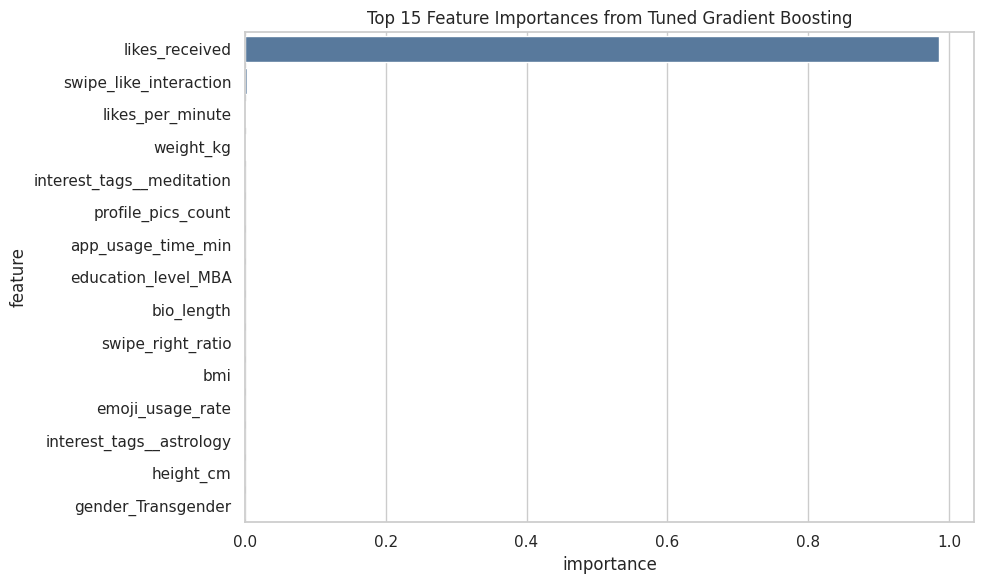

Training feature-selection model: SelectKBest top 10
Training feature-selection model: SelectKBest top 20
Training feature-selection model: SelectKBest top 30
Training feature-selection model: All preprocessed features


,MAE,RMSE,R2,RMSE Improvement vs Dummy
Feature Set,,,,
SelectKBest top 30,7.154932,8.478082,0.128963,0.606266
SelectKBest top 10,7.154475,8.478267,0.128925,0.606080
SelectKBest top 20,7.155335,8.478973,0.128780,0.605375
All preprocessed features,7.158631,8.481790,0.128201,0.602558


Computing permutation importance on a 2,000-row test sample...


,feature,importance_mean,importance_std
8,likes_received,1.050514,0.048486
23,swipe_like_interaction,0.002732,0.000916
9,profile_pics_count,0.001224,0.000999
4,education_level,0.000729,0.000373
12,emoji_usage_rate,0.000000,0.000245
1,sexual_orientation,0.000000,0.000000
3,income_bracket,0.000000,0.000000
11,message_sent_count,0.000000,0.000000
13,last_active_hour,0.000000,0.000000
22,messages_per_minute,0.000000,0.000000


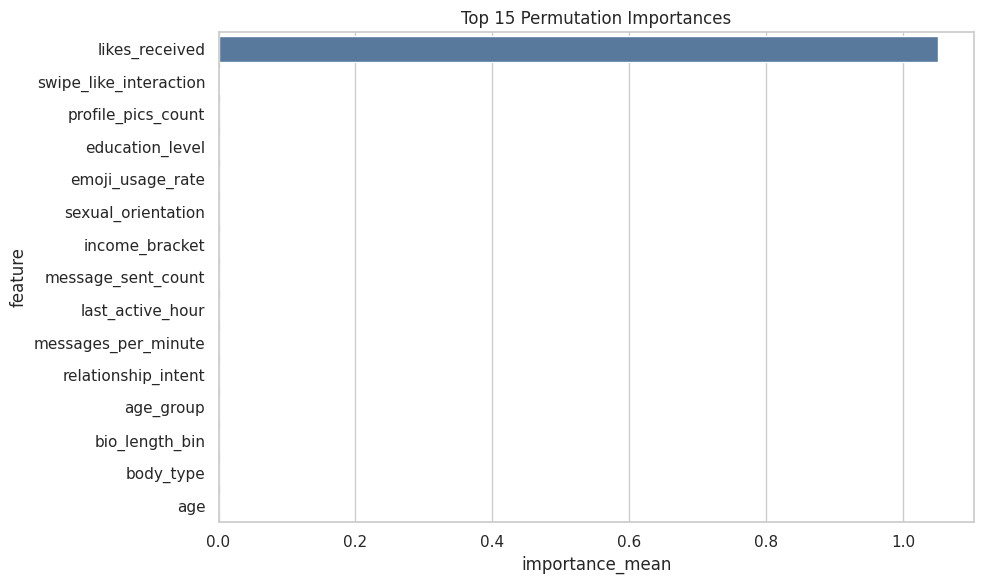

In [ ]:
feature_names = get_feature_names(final_model.named_steps["preprocessor"])
final_estimator = final_model.named_steps["model"]

if hasattr(final_estimator, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": final_estimator.feature_importances_,
    }).sort_values("importance", ascending=False)

    display(
        importance_df.head(15).style.format({
            "importance": "{:.6f}",
        })
    )

    plt.figure(figsize=(10, 6))
    sns.barplot(data=importance_df.head(15), x="importance", y="feature", color="#4C78A8")
    plt.title(f"Top 15 Feature Importances from {final_model_name}")
    plt.tight_layout()
    plt.show()
else:
    print(f"{final_model_name} does not expose built-in feature_importances_.")

# SelectKBest feature selection using mutual information.
selection_rows = []
selection_models = {}

for k in [10, 20, 30, "all"]:
    model_label = f"SelectKBest top {k}" if k != "all" else "All preprocessed features"
    print(f"Training feature-selection model: {model_label}")

    steps = [("preprocessor", build_preprocessor(X_train))]

    if k != "all":
        steps.append(("selector", SelectKBest(score_func=mutual_info_regression, k=k)))

    steps.append(("model", clone(final_estimator)))

    selection_pipeline = Pipeline(steps)
    selection_pipeline.fit(X_train, y_train)

    selection_pred = np.clip(selection_pipeline.predict(X_test), 0, 30)
    selection_metrics = calculate_regression_metrics(y_test, selection_pred)
    selection_metrics["Feature Set"] = model_label

    selection_rows.append(selection_metrics)
    selection_models[model_label] = selection_pipeline

feature_selection_results = (
    pd.DataFrame(selection_rows)
    .set_index("Feature Set")
    .sort_values("R2", ascending=False)
)

feature_selection_results["RMSE Improvement vs Dummy"] = (
    dummy_metrics["RMSE"] - feature_selection_results["RMSE"]
)

display(
    feature_selection_results.style.format({
        "MAE": "{:.6f}",
        "RMSE": "{:.6f}",
        "R2": "{:.6f}",
        "RMSE Improvement vs Dummy": "{:.6f}",
    })
)

print("Computing permutation importance on a 2,000-row test sample...")

sample_n = min(2000, len(X_test))
X_perm = X_test.sample(n=sample_n, random_state=RANDOM_STATE)
y_perm = y_test.loc[X_perm.index]

perm = permutation_importance(
    final_model,
    X_perm,
    y_perm,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_perm.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

display(
    perm_df.head(15).style.format({
        "importance_mean": "{:.6f}",
        "importance_std": "{:.6f}",
    })
)

plt.figure(figsize=(10, 6))
sns.barplot(data=perm_df.head(15), x="importance_mean", y="feature", color="#4C78A8")
plt.title("Top 15 Permutation Importances")
plt.tight_layout()
plt.show()

## 15. AutoML Benchmark

The assignment asks for comparison with auto-sklearn. Since auto-sklearn was difficult to run in Colab, we used FLAML as an AutoML benchmark and compared it with our manually tuned models.


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.utils.validation")

automl_preprocessor = build_preprocessor(X_train)
X_train_automl = automl_preprocessor.fit_transform(X_train)
X_test_automl = automl_preprocessor.transform(X_test)

automl = AutoML()
automl_settings = {
    "time_budget": 120,
    "metric": "rmse",
    "task": "regression",
    "seed": RANDOM_STATE,
    "n_jobs": -1,
    "verbose": 1,
}

automl.fit(X_train_automl, y_train, **automl_settings)
automl_predictions = np.clip(automl.predict(X_test_automl), 0, 30)
automl_metrics = calculate_regression_metrics(y_test, automl_predictions)

print(f"FLAML RMSE: {automl_metrics['RMSE']:.4f}")
print(f"FLAML R2: {automl_metrics['R2']:.4f}")
print(f"FLAML best estimator: {automl.best_estimator}")
print("FLAML best configuration:")
display(pd.Series(automl.best_config).to_frame("value"))

comparison_to_automl = pd.concat(
    [
        pd.DataFrame([final_metrics], index=[final_model_name]),
        pd.DataFrame([automl_metrics], index=["FLAML AutoML"]),
    ]
)
display(comparison_to_automl[["MAE", "RMSE", "R2"]])


INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


FLAML RMSE: 8.4878
FLAML R2: 0.1270
FLAML best estimator: extra_tree
FLAML best configuration:


,value
n_estimators,4.000000
max_features,0.772403
max_leaves,26.000000


,MAE,RMSE,R2
Tuned Gradient Boosting,7.158631,8.481790,0.128201
FLAML AutoML,7.168174,8.487755,0.126974


The FLAML AutoML benchmark produced performance that was very close to the manually tuned final model. This suggests that the main limitation is unlikely to be the choice of algorithm alone. Instead, the available features may only contain limited predictive signal for mutual_matches.

## 16. Sensitivity Analysis: Engagement Feature Dependence

We compare the final model using the main feature set with the same model family trained without like-related and message-related engagement features.


In [ ]:
safe_estimator = clone(final_model.named_steps["model"])

safe_pipeline = Pipeline(
    steps=[
        ("preprocessor", build_preprocessor(X_train_safe)),
        ("model", safe_estimator),
    ]
)

safe_pipeline.fit(X_train_safe, y_train_safe)

safe_predictions = np.clip(safe_pipeline.predict(X_test_safe), 0, 30)

safe_metrics = calculate_regression_metrics(y_test_safe, safe_predictions)

# Add this so the reduced-engagement row does not show NaN
safe_metrics["RMSE Improvement vs Dummy"] = dummy_metrics["RMSE"] - safe_metrics["RMSE"]

sensitivity_comparison = pd.DataFrame(
    [
        {
            "Model": final_model_name + " (main features)",
            **final_metrics.to_dict(),
        },
        {
            "Model": final_model_name + " (reduced engagement features)",
            **safe_metrics,
        },
    ]
).set_index("Model")

display(sensitivity_comparison)

,MAE,RMSE,R2,RMSE Improvement vs Dummy
Model,,,,
Tuned Gradient Boosting (main features),7.158631,8.481790,0.128201,0.602558
Tuned Gradient Boosting (reduced engagement features),7.893283,9.089549,-0.001212,-0.005201


The reduced-engagement model performed much worse than the main model. This shows that engagement-related features such as likes and message activity contributed strongly to prediction performance. Therefore, profile-only predictions should be interpreted carefully.


## 17. Final Model Evaluation and Error Analysis

We evaluate the selected final model using residual plots, actual-vs-predicted values, and MAE by low, medium, and high mutual match ranges.


,MAE,RMSE,R2
Model,,,
Tuned Gradient Boosting,7.158631,8.48179,0.128201


,count,MAE,RMSE,mean_actual,mean_predicted
target_range,,,,,
low (0-10),4110,8.248500,9.327783,4.623358,12.653444
medium (11-20),3123,2.736690,3.222507,15.539866,14.555594
high (21-30),2767,10.530643,10.910412,25.506686,14.976043


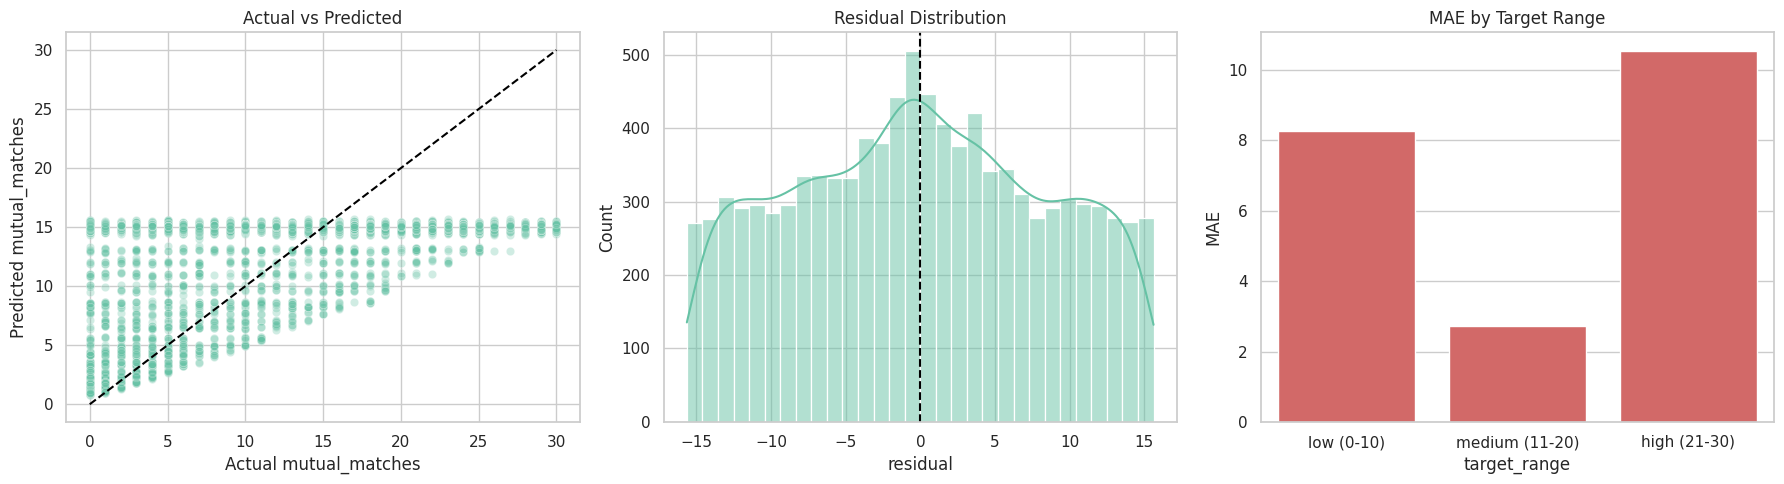

In [ ]:
final_predictions = np.clip(final_model.predict(X_test), 0, 30)
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": final_predictions,
})
error_df["residual"] = error_df["actual"] - error_df["predicted"]
error_df["absolute_error"] = error_df["residual"].abs()
error_df["target_range"] = pd.cut(error_df["actual"], bins=[-0.1, 10, 20, 30], labels=["low (0-10)", "medium (11-20)", "high (21-30)"])

final_metric_table = pd.DataFrame([{ "Model": final_model_name, **calculate_regression_metrics(y_test, final_predictions) }]).set_index("Model")
display(final_metric_table)

range_errors = error_df.groupby("target_range", observed=False).agg(
    count=("absolute_error", "count"),
    MAE=("absolute_error", "mean"),
    RMSE=("residual", lambda values: np.sqrt(np.mean(values ** 2))),
    mean_actual=("actual", "mean"),
    mean_predicted=("predicted", "mean"),
)
display(range_errors)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=error_df, x="actual", y="predicted", alpha=0.30, ax=axes[0])
axes[0].plot([0, 30], [0, 30], color="black", linestyle="--")
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual mutual_matches")
axes[0].set_ylabel("Predicted mutual_matches")

sns.histplot(error_df["residual"], bins=30, kde=True, ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Residual Distribution")

sns.barplot(data=range_errors.reset_index(), x="target_range", y="MAE", color="#E45756", ax=axes[2])
axes[2].set_title("MAE by Target Range")
plt.tight_layout()
plt.show()


The final model performed better for medium mutual match counts than for very low or very high values. This means the model tends to predict closer to the middle of the target range, causing it to overpredict low-match users and underpredict high-match users.

## 18. Ethical Considerations

This dataset is synthetic, so the results should be treated as a machine learning exercise rather than evidence about real dating behaviour. Even with real data, predicting match potential could raise fairness and privacy concerns because demographic and behavioural features may reflect social bias.

The model should not be used to judge real users, rank people, or make strong claims about relationship success. The results are useful for learning about preprocessing, model comparison, feature importance, and evaluation limits, but they should be interpreted carefully.


## 19. Conclusion and Limitations

This section summarizes the final model performance, key insights, and limitations.


In [ ]:
final_summary_rows = [
    {
        "Question": "Best manual model",
        "Answer": final_model_name,
        "Evidence": f"RMSE={final_metrics['RMSE']:.3f}, R2={final_metrics['R2']:.3f}",
    },
    {
        "Question": "Improvement over baseline",
        "Answer": "The final model improved over DummyRegressor" if final_metrics["RMSE"] < dummy_metrics["RMSE"] else "The final model did not improve over DummyRegressor",
        "Evidence": f"Dummy RMSE={dummy_metrics['RMSE']:.3f}; final RMSE={final_metrics['RMSE']:.3f}; improvement={dummy_metrics['RMSE'] - final_metrics['RMSE']:.3f}",
    },
    {
        "Question": "AutoML comparison",
        "Answer": "FLAML was used as the AutoML benchmark because auto-sklearn was difficult to run in Colab",
        "Evidence": f"FLAML RMSE={automl_metrics['RMSE']:.3f}, R2={automl_metrics['R2']:.3f}; final RMSE={final_metrics['RMSE']:.3f}, R2={final_metrics['R2']:.3f}",
    },
    {
        "Question": "Sensitivity analysis",
        "Answer": "Engagement-related features contributed strongly to performance",
        "Evidence": f"Main R2={final_metrics['R2']:.3f}; reduced-engagement R2={safe_metrics['R2']:.3f}",
    },
    {
        "Question": "Limitation",
        "Answer": "The target is only modestly predictable from the available features",
        "Evidence": "Residual analysis and sensitivity analysis show substantial unexplained variation.",
    },
]

final_summary = pd.DataFrame(final_summary_rows)

styled_final_summary = (
    final_summary.style
    .set_properties(
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Question"],
        **{
            "min-width": "170px",
            "max-width": "220px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Answer"],
        **{
            "min-width": "300px",
            "max-width": "420px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_properties(
        subset=["Evidence"],
        **{
            "min-width": "360px",
            "max-width": "520px",
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "middle",
        }
    )
    .set_table_styles([
        {
            "selector": "th",
            "props": [
                ("text-align", "left"),
                ("vertical-align", "middle"),
                ("white-space", "normal"),
                ("font-weight", "bold"),
            ],
        },
        {
            "selector": "td",
            "props": [
                ("text-align", "left"),
                ("vertical-align", "middle"),
                ("white-space", "normal"),
            ],
        },
    ])
)

display(styled_final_summary)


,Question,Answer,Evidence
0,Best manual model,Tuned Gradient Boosting,"RMSE=8.482, R2=0.128"
1,Improvement over baseline,The final model improved over DummyRegressor,Dummy RMSE=9.084; final RMSE=8.482; improvement=0.603
2,AutoML comparison,FLAML was used as the AutoML benchmark because auto-sklearn was difficult to run in Colab,"FLAML RMSE=8.488, R2=0.127; final RMSE=8.482, R2=0.128"
3,Sensitivity analysis,Engagement-related features contributed strongly to performance,Main R2=0.128; reduced-engagement R2=-0.001
4,Limitation,The target is only modestly predictable from the available features,Residual analysis and sensitivity analysis show substantial unexplained variation.


### Final Conclusion

We predicted `mutual_matches` as a bounded count regression target to estimate dating app match potential. The final selected model was **Tuned Gradient Boosting**, which achieved an RMSE of **8.482** and an R² of **0.128** on the test set.

Compared with the `DummyRegressor` baseline RMSE of **9.084**, the final model reduced RMSE by **0.603**. This shows that the dataset contains some predictive signal, although the low R² indicates that most variation in mutual match count remains unexplained.

The manually tuned Gradient Boosting model slightly outperformed the FLAML AutoML benchmark. FLAML achieved an RMSE of **8.488** and an R² of **0.127**, which is very close to the final manual model. This suggests that model choice is not the only limitation; the available features may not contain enough information to strongly predict mutual match count.

Feature importance and permutation importance showed that `likes_received` was the dominant predictor. The sensitivity analysis also showed a major performance drop, with R² decreasing from **0.128** to **-0.001** after removing engagement-related features. This indicates that likes and message-related activity contributed strongly to the model’s performance, while profile-only predictions should be interpreted carefully.

The error analysis showed that the model performed best for medium mutual match counts but struggled with extreme values. It tended to overpredict users with low mutual matches and underpredict users with high mutual matches.

Overall, the final model predicted mutual match count better than a simple baseline, but the performance remained modest. Therefore, this model should be used only for educational analysis and should not be used to judge real users, attractiveness, compatibility, or relationship success.